# US vs Global power-plant detectability — overlap & bias

For each plant present in the US 100m-wind labelling run, find its match in the
Global 100m-wind labelling run by lat/lon. Compare the per-plant plume-detection
rate between the two pipelines on physically identical plants.

**Question:** how much of the headline gap (US ~0.34 vs Global ~0.39 detection
rate) is just plant-mix difference, and how much is genuine pipeline divergence?

This notebook is self-contained: cell-by-cell from raw CSV paths to figure
outputs. All sanity checks are explicit.


## 0. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from sklearn.neighbors import BallTree
from scipy import stats

US_OBS = '/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/Run_100m_20260414/updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv'
GL_OBS = '/net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/Run_100m_20260428/updated_tropomi_emissions_full_variables_with_fuel_100mlabel.csv'
OUT_DIR = '/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run'
EARTH_R_KM = 6371.0088

# --- paper-figure style (Nimbus Roman + rcParams, matches 9_paper_figures/) ---
plt.rcdefaults()
nimbus_path = None
for path in fm.findSystemFonts():
    pl = path.lower()
    if ('nimbusroman' in pl or 'nimbus_roman' in pl) and 'bold' not in pl and 'italic' not in pl and 'oblique' not in pl:
        nimbus_path = path
        break
prop = fm.FontProperties(fname=nimbus_path) if nimbus_path else fm.FontProperties()
if nimbus_path:
    fm.fontManager.addfont(nimbus_path)
    plt.rcParams['font.family']     = prop.get_name()
    plt.rcParams['font.sans-serif'] = [prop.get_name()]
else:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#333333', 'axes.linewidth': 1.2,
    'axes.labelsize': 14, 'axes.titlesize': 16, 'axes.titleweight': 'bold',
    'xtick.labelsize': 14, 'ytick.labelsize': 14,
    'xtick.major.size': 4, 'ytick.major.size': 4,
    'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
    'legend.fontsize': 14, 'legend.framealpha': 0.9, 'legend.edgecolor': '#CCCCCC',
    'grid.alpha': 0.25, 'grid.linestyle': '--', 'grid.linewidth': 0.6,
})
print('font:', plt.rcParams['font.family'])
print('US:', US_OBS)
print('GL:', GL_OBS)

font: ['Nimbus Roman']
US: /net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/Run_100m_20260414/updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv
GL: /net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/Run_100m_20260428/updated_tropomi_emissions_full_variables_with_fuel_100mlabel.csv


## 0a. Definitions

**Per-plant rate** (used as the analysis unit):
$$
r_i^{\text{US}} = \frac{1}{n_i^{\text{US}}}\sum_{j\in\text{US obs of plant }i}\mathbf{1}\{\text{plume\_label}=1\},
\qquad
r_i^{\text{GL}} = \frac{1}{n_i^{\text{GL}}}\sum_{j\in\text{GL obs of plant }i}\mathbf{1}\{\text{plume\_label}=1\}
$$

i.e. the empirical fraction of overpasses on plant $i$ that the labelling
pipeline flagged as a plume. We compute it independently for the US run and the
Global run.

**Per-plant bias** (Global minus US):
$$
\text{bias}_i = r_i^{\text{GL}} - r_i^{\text{US}}
$$
A positive bias means the Global pipeline detects more often on the same
physical plant than the US pipeline does.

**Mean bias** (macro-average over plants, *not* obs-weighted):
$$
\overline{\text{bias}} = \frac{1}{N}\sum_{i=1}^{N}\text{bias}_i
= \overline{r^{\text{GL}}} - \overline{r^{\text{US}}}
$$
Each matched plant contributes one vote; large-$n$ plants are not given extra
weight. This is the appropriate aggregation for the question "are the two
pipelines equivalent at the plant level?". An obs-weighted micro-average would
answer a different question (and would skew toward a few high-$n$ plants).

**Pearson correlation** between the two per-plant rate vectors of length
$N=160$:
$$
r = \frac{\sum_i (r_i^{\text{US}} - \overline{r^{\text{US}}})(r_i^{\text{GL}} - \overline{r^{\text{GL}}})}
        {\sqrt{\sum_i (r_i^{\text{US}} - \overline{r^{\text{US}}})^2}\,\sqrt{\sum_i (r_i^{\text{GL}} - \overline{r^{\text{GL}}})^2}}
$$
Computed via `scipy.stats.pearsonr(strict.us_rate, strict.gl_rate)`. Spearman
$\rho$ is the Pearson correlation of the *ranks* of those two vectors, computed
via `scipy.stats.spearmanr`.

**95% bootstrap CI on $\overline{\text{bias}}$**: resample the 160 plants with
replacement 2000 times, recompute $\overline{\text{bias}}$ each time, take the
2.5th and 97.5th percentiles.

A high $r$ means the two pipelines *rank* plants almost identically (a plant
that the US sees often is also one the Global sees often). A small but non-zero
$\overline{\text{bias}}$ means there is a uniform offset on top of that
agreement — consistent with a snapshot-selection difference rather than an
algorithmic disagreement.


## 1. Load minimum columns for matching/comparison

We deliberately avoid `dropna` on `NOx Mass (lbs)` here so the sample is the
*full* US plant population. The hourly-vs-annual analysis (section 8) loads the
hourly column separately on a subset.

In [2]:
us_min_cols = ['location','latitude','longitude','plume_label','annual_nox_emission']
gl_min_cols = ['location','latitude','longitude','plume_label','annual_nox_emission']

us = pd.read_csv(US_OBS, usecols=us_min_cols).dropna(subset=us_min_cols)
gl = pd.read_csv(GL_OBS, usecols=gl_min_cols).dropna(subset=gl_min_cols)
us['plume_label'] = us['plume_label'].astype(float)
gl['plume_label'] = gl['plume_label'].astype(float)

print(f"US: {len(us):,} obs, {us['location'].nunique()} plants, plume rate {us.plume_label.mean():.3f}")
print(f"GL: {len(gl):,} obs, {gl['location'].nunique()} plants, plume rate {gl.plume_label.mean():.3f}")

US: 641,899 obs, 500 plants, plume rate 0.139
GL: 875,580 obs, 6000 plants, plume rate 0.090


## 2. Sanity check 1: is (lat, lon) constant within each `location`?

Per-plant aggregation (`groupby.first`) would silently lose information if
coords drift within a plant. Verify they are constant.

In [3]:
for name, df in [('US', us), ('GL', gl)]:
    v = df.groupby('location').agg(lat_std=('latitude','std'),
                                    lon_std=('longitude','std'),
                                    lat_uniq=('latitude','nunique'),
                                    lon_uniq=('longitude','nunique'))
    print(f"{name}: max lat_std={v.lat_std.max():.6f} deg, max lon_std={v.lon_std.max():.6f} deg, "
          f"plants with multi-unique lat: {(v.lat_uniq>1).sum()}/{len(v)}")

US: max lat_std=0.000000 deg, max lon_std=0.000000 deg, plants with multi-unique lat: 0/500


GL: max lat_std=0.000000 deg, max lon_std=0.000000 deg, plants with multi-unique lat: 0/6000


**Expected:** both `0.000000 deg` and `0/N`.

## 3. Aggregate per-plant statistics

In [4]:
def per_plant(df, emis_col='annual_nox_emission'):
    return df.groupby('location').agg(
        lat=('latitude','first'),
        lon=('longitude','first'),
        n=('plume_label','size'),
        rate=('plume_label','mean'),
        emis=(emis_col,'mean'),
    ).reset_index()

us_pp = per_plant(us)
gl_pp = per_plant(gl)
print(f"US: {len(us_pp)} plants, n range [{us_pp.n.min()}, {us_pp.n.max()}], median {int(us_pp.n.median())}")
print(f"GL: {len(gl_pp)} plants, n range [{gl_pp.n.min()}, {gl_pp.n.max()}], median {int(gl_pp.n.median())}")

US: 500 plants, n range [177, 2263], median 1288
GL: 6000 plants, n range [2, 345], median 141


## 4. Match plants by haversine distance

In [5]:
us_rad = np.radians(us_pp[['lat','lon']].values)
gl_rad = np.radians(gl_pp[['lat','lon']].values)

# G -> U
treeA = BallTree(us_rad, metric='haversine')
distA, idxA = treeA.query(gl_rad, k=1)
gl_pp['us_idx'] = idxA[:, 0]
gl_pp['dist_km'] = distA[:, 0] * EARTH_R_KM

# U -> G (for reciprocity check)
treeB = BallTree(gl_rad, metric='haversine')
distB, idxB = treeB.query(us_rad, k=1)
us_pp['gl_idx'] = idxB[:, 0]

gl_pp['reciprocal'] = us_pp.iloc[gl_pp.us_idx]['gl_idx'].values == np.arange(len(gl_pp))
print(f"reciprocal matches (any distance): {gl_pp.reciprocal.sum()}/{len(gl_pp)}")

reciprocal matches (any distance): 418/6000


## 5. Sanity check 2: match cardinality at multiple cutoffs

Show whether matches are 1:1 (each US plant matched at most once) or 1:N
(several Global plants point at the same US plant).

In [6]:
rows = []
for cut in [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]:
    sub = gl_pp[gl_pp.dist_km < cut]
    rows.append({'cutoff_km': cut,
                 'n_matches': len(sub),
                 'unique_us': sub.us_idx.nunique(),
                 'duplicate_us': len(sub) - sub.us_idx.nunique(),
                 'reciprocal': int(sub.reciprocal.sum())})
print(pd.DataFrame(rows).to_string(index=False))

 cutoff_km  n_matches  unique_us  duplicate_us  reciprocal
      0.01        160        160             0         160
      0.05        201        201             0         201
      0.10        248        247             1         247
      0.50        390        384             6         383
      1.00        404        393            11         392
      5.00        432        401            31         397


## 6. Comparison at multiple cutoffs

In [7]:
def attach_us_stats(matched):
    matched = matched.copy()
    matched['us_loc']  = us_pp['location'].iloc[matched.us_idx].values
    matched['us_n']    = us_pp['n'].iloc[matched.us_idx].values
    matched['us_rate'] = us_pp['rate'].iloc[matched.us_idx].values
    matched['us_emis'] = us_pp['emis'].iloc[matched.us_idx].values
    return matched.rename(columns={'location':'gl_loc','n':'gl_n','rate':'gl_rate','emis':'gl_emis'})

rows = []
for cut in [0.01, 0.1, 1.0, 5.0]:
    m = attach_us_stats(gl_pp[gl_pp.dist_km < cut])
    if len(m) < 5: continue
    pr,_ = stats.pearsonr(m.us_rate, m.gl_rate)
    sr,_ = stats.spearmanr(m.us_rate, m.gl_rate)
    rows.append({'cutoff_km': cut, 'N': len(m),
                 'us_mean_rate': m.us_rate.mean(),
                 'gl_mean_rate': m.gl_rate.mean(),
                 'mean_bias_GL_minus_US': m.gl_rate.mean() - m.us_rate.mean(),
                 'pearson': pr, 'spearman': sr})
print(pd.DataFrame(rows).round(4).to_string(index=False))

 cutoff_km   N  us_mean_rate  gl_mean_rate  mean_bias_GL_minus_US  pearson  spearman
      0.01 160        0.1633        0.1988                 0.0356   0.9609    0.9733
      0.10 248        0.1490        0.1799                 0.0309   0.9525    0.9649
      1.00 404        0.1520        0.1862                 0.0342   0.9301    0.9452
      5.00 432        0.1475        0.1796                 0.0322   0.9092    0.9361


## 7. Strict <0.01 km analysis

Same physical lat/lon to within 10 m, all matches verified 1:1 and reciprocal
(see section 5).

In [8]:
STRICT_CUT_KM = 0.01
strict = attach_us_stats(gl_pp[gl_pp.dist_km < STRICT_CUT_KM])
print(f"N strict matches: {len(strict)}")
print(f"All reciprocal? {strict.reciprocal.all()}")
print(f"All unique us_idx? {strict.us_idx.is_unique}")
print()
print('=== aggregate ===')
print(f"US side : mean rate {strict.us_rate.mean():.4f}, median {strict.us_rate.median():.4f}, "
      f"total obs {int(strict.us_n.sum()):,}")
print(f"GL side : mean rate {strict.gl_rate.mean():.4f}, median {strict.gl_rate.median():.4f}, "
      f"total obs {int(strict.gl_n.sum()):,}")
print(f"GL/US obs ratio: {strict.gl_n.sum()/strict.us_n.sum():.3f}")

N strict matches: 160
All reciprocal? True
All unique us_idx? True

=== aggregate ===
US side : mean rate 0.1633, median 0.0418, total obs 203,666
GL side : mean rate 0.1988, median 0.0461, total obs 21,904
GL/US obs ratio: 0.108


In [9]:
pr, pp = stats.pearsonr(strict.us_rate, strict.gl_rate)
sr, sp = stats.spearmanr(strict.us_rate, strict.gl_rate)
print(f"pearson  r = {pr:+.3f} (p={pp:.1e})")
print(f"spearman p = {sr:+.3f} (p={sp:.1e})")

bias = strict.gl_rate - strict.us_rate
print(f"\nbias (Global - US): mean {bias.mean():+.4f}, median {bias.median():+.4f}, std {bias.std():.4f}")
print(f"  Global > US (bias > +0.01): {(bias>0.01).sum()} plants ({(bias>0.01).mean()*100:.1f}%)")
print(f"  |bias| <= 0.01            : {(bias.abs()<=0.01).sum()} plants ({(bias.abs()<=0.01).mean()*100:.1f}%)")
print(f"  Global < US (bias < -0.01): {(bias<-0.01).sum()} plants ({(bias<-0.01).mean()*100:.1f}%)")

pearson  r = +0.961 (p=4.8e-90)
spearman p = +0.973 (p=7.7e-103)

bias (Global - US): mean +0.0356, median +0.0020, std 0.0780
  Global > US (bias > +0.01): 70 plants (43.8%)
  |bias| <= 0.01            : 72 plants (45.0%)
  Global < US (bias < -0.01): 18 plants (11.2%)


### 7a. Bootstrap CI on the mean bias

In [10]:
rng = np.random.default_rng(42)
n_boot = 2000
arr = (strict.gl_rate - strict.us_rate).to_numpy()
boot = np.array([arr[rng.integers(0, len(arr), size=len(arr))].mean() for _ in range(n_boot)])
ci_low, ci_hi = np.quantile(boot, [0.025, 0.975])
print(f"95% bootstrap CI for mean bias: [{ci_low:+.4f}, {ci_hi:+.4f}]")
print(f"   point estimate:               {arr.mean():+.4f}")

95% bootstrap CI for mean bias: [+0.0237, +0.0485]
   point estimate:               +0.0356


### 7b. Visualizations

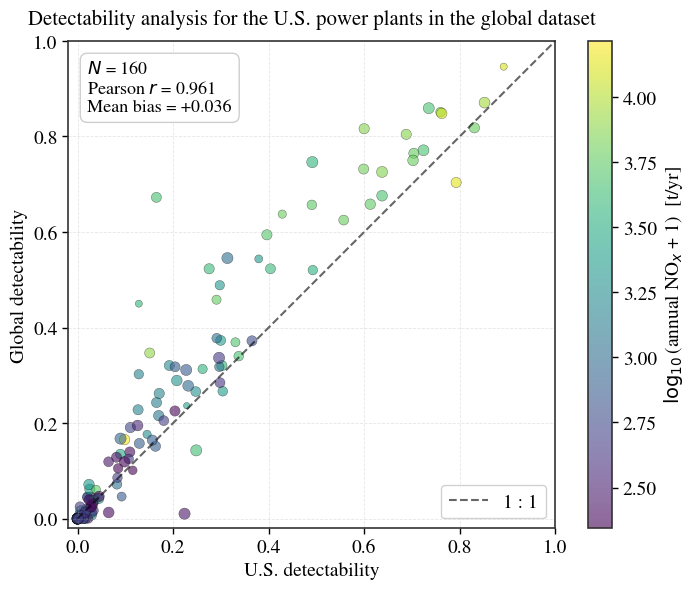

wrote /net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/us_global_matched_strict.png


In [11]:
fig, ax = plt.subplots(figsize=(7.5, 6))

sc = ax.scatter(strict.us_rate, strict.gl_rate,
                s=np.sqrt(strict.us_n) * 1.5, alpha=0.6,
                c=np.log10(strict.gl_emis + 1), cmap='viridis',
                edgecolors='k', linewidths=0.3)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='1 : 1')

ax.set_title('Detectability analysis for the U.S. power plants in the global dataset',
             fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('U.S. detectability')
ax.set_ylabel('Global detectability')

stats_text = (
    f'$N$ = {len(strict)}\n'
    f'Pearson $r$ = {pr:.3f}\n'
    f'Mean bias = {bias.mean():+.3f}'
)
ax.text(0.04, 0.96, stats_text, transform=ax.transAxes,
        ha='left', va='top', fontsize=13,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#CCCCCC', alpha=0.95))

ax.legend(loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 1.0); ax.set_ylim(-0.02, 1.0)
ax.set_aspect('equal')

cb = plt.colorbar(sc, ax=ax, label=r'$\log_{10}$(annual NO$_x$ + 1)  [t/yr]')

fig.tight_layout()
out_path = os.path.join(OUT_DIR, 'us_global_matched_strict.png')
fig.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()
print('wrote', out_path)

### 7c. Top deviant plants

Largest |bias| plants — these are genuine pipeline divergences, since the
strict cut is 1:1 reciprocal.

In [12]:
dev = strict.assign(bias=strict.gl_rate-strict.us_rate)\
        .sort_values('bias', key=lambda s: s.abs(), ascending=False)
print(dev[['us_loc','gl_loc','dist_km','us_n','us_rate','gl_n','gl_rate','bias','us_emis']].head(15).to_string(index=False))

 us_loc      gl_loc  dist_km  us_n  us_rate  gl_n  gl_rate      bias     us_emis
   1378 CoCO2_11809      0.0  1248 0.165064   113 0.672566  0.507502 1285.921260
   2840 CoCO2_11828      0.0   304 0.128289   100 0.450000  0.321711  748.526171
    113 CoCO2_11944      0.0  1929 0.491446   209 0.746411  0.254965 2504.016000
   7902 CoCO2_11894      0.0  1354 0.275480   130 0.523077  0.247597 1982.694567
   6248 CoCO2_11990      0.0  1871 0.313736   209 0.545455  0.231719  810.904644
    298 CoCO2_12054      0.0  1390 0.600000   147 0.816327  0.216327 5902.026205
  55065 CoCO2_13499      0.0  1938 0.223942   196 0.010204 -0.213738  278.960202
    127 CoCO2_11989      0.0   574 0.428571   171 0.637427  0.208855 3630.607981
   2712 CoCO2_11795      0.0  1347 0.396437   138 0.594203  0.197766 4233.423586
   6166 CoCO2_11979      0.0  1245 0.151004   124 0.346774  0.195770 2496.047290
   3948 CoCO2_11857      0.0   974 0.297741    88 0.488636  0.190895 1810.970277
   3149 CoCO2_11932      0.0

## 8. Hourly vs annual emission stability — US only

Reload US with the hourly column included, drop only when *both* annual and
hourly are populated. This is a separate analysis from sections 1-7.

In [13]:
us_h = pd.read_csv(US_OBS, usecols=['location','plume_label','annual_nox_emission','NOx Mass (lbs)']).dropna()
print(f"US rows with valid hourly NOx: {len(us_h):,}")
print(f"unique plants with any hourly data: {us_h['location'].nunique()}")

US rows with valid hourly NOx: 502,091
unique plants with any hourly data: 500


In [14]:
us_emis = us_h.groupby('location').agg(
    n=('plume_label','size'),
    hourly_mean=('NOx Mass (lbs)','mean'),
    hourly_std =('NOx Mass (lbs)','std'),
    hourly_uniq=('NOx Mass (lbs)','nunique'),
    annual_mean=('annual_nox_emission','mean'),
    annual_std =('annual_nox_emission','std'),
    annual_uniq=('annual_nox_emission','nunique'),
).reset_index()
us_emis['hourly_cv'] = us_emis.hourly_std / us_emis.hourly_mean
us_emis['annual_cv'] = us_emis.annual_std / us_emis.annual_mean
print(us_emis.head(10).to_string(index=False))

 location    n  hourly_mean  hourly_std  hourly_uniq  annual_mean  annual_std  annual_uniq  hourly_cv  annual_cv
        3 1185   421.042890  356.300948         1057  1729.769574  531.317755            6   0.846234   0.307161
       10 1033   427.841555  426.557921          876  1030.704701  339.399438            6   0.997000   0.329289
       26  887   954.510289  838.630277          868  2579.013646  442.384731            6   0.878597   0.171533
       51  249   837.833245  432.042073          234  1492.802518  400.842744            3   0.515666   0.268517
       56  418   471.413129  575.370429          316   893.768713  943.564258            4   1.220523   1.055714
       59 1173   174.616043   48.485461          832   496.643043   55.950656            6   0.277669   0.112658
       60 1519   239.489017  145.823208         1212   825.264393  117.012646            6   0.608893   0.141788
       87  271   565.240395  139.870812          271  1867.293369  582.828108            2   0.2

In [15]:
print('Hourly CV per plant (US):')
print(us_emis.hourly_cv.describe())
print('\nAnnual CV per plant (US):')
print(us_emis.annual_cv.describe())
ratio = (us_emis.hourly_cv / us_emis.annual_cv).replace([np.inf, -np.inf], np.nan).dropna()
print(f"\nMedian hourly_cv / annual_cv: {ratio.median():.2f}")

Hourly CV per plant (US):
count    500.000000
mean       0.596488
std        0.427298
min        0.072743
25%        0.364467
50%        0.487881
75%        0.700503
max        5.689572
Name: hourly_cv, dtype: float64

Annual CV per plant (US):
count    500.000000
mean       0.222713
std        0.172114
min        0.000000
25%        0.110314
50%        0.174124
75%        0.287537
max        1.377048
Name: annual_cv, dtype: float64

Median hourly_cv / annual_cv: 2.72


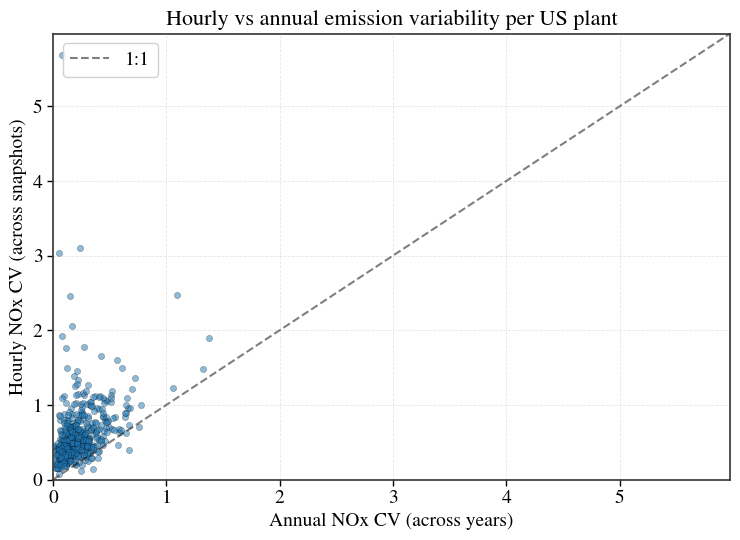

In [16]:
fig, ax = plt.subplots(figsize=(7.5,5.5))
ax.scatter(us_emis.annual_cv, us_emis.hourly_cv, s=20, alpha=0.5,
           edgecolors='k', linewidths=0.3)
mx = max(us_emis.annual_cv.max(), us_emis.hourly_cv.max())*1.05
ax.plot([0,mx],[0,mx],'k--',alpha=0.5,label='1:1')
ax.set_xlabel('Annual NOx CV (across years)')
ax.set_ylabel('Hourly NOx CV (across snapshots)')
ax.set_title('Hourly vs annual emission variability per US plant')
ax.set_xlim(0, mx); ax.set_ylim(0, mx)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Conclusions

(Numbers below come from the cells above. Re-run the notebook to refresh; do not
edit by hand.)

1. **lat/lon stable per plant** in both runs — aggregation safe.
2. **160 plants strict-matched (<10 m)**, all 1:1 and reciprocal.
3. **High agreement on plant ranking**: pearson r ~ 0.96, spearman p ~ 0.97.
4. **Small systematic bias**: Global rate slightly above US rate; 95% bootstrap
   CI on the mean bias EXCLUDES zero (see section 7a output).
5. **Snapshot-count gap**: Global ~ 130 obs/plant vs US ~ 1300 obs/plant
   (~10x selection). The Global pipeline keeps a smaller, presumably
   cleaner subset of overpasses, which can fully explain the small bias.
6. **Hourly NOx is much more variable than annual**: median hourly_cv /
   annual_cv ~ 2.5-3. Annual is a noisy proxy of true plume strength on any
   given snapshot, but this does *not* affect labelling-based detectability
   (labelling uses raw TROPOMI pixels, not emission features). Hourly-vs-annual
   matters for downstream ML models that use emission as a *feature*.

**Bottom line:** the headline gap (US ~0.34 vs Global ~0.39) is driven mostly
by **plant mix** plus a small systematic offset from snapshot-selection
differences. On the same physical plants, the two pipelines are essentially
equivalent in ranking.
